# Project Scenario 1: Smart Waste Classification System

A city municipality wants to build an AI-powered waste segregation system that can automatically classify images of waste into:

Recyclable Waste

Organic Waste

Non-Recyclable Waste

You are required to build a deep learning image classifier that can perform this task.

Task 1 – Dataset Collection (5 Marks)
Download or collect a dataset of waste images from sources

https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification?utm_source=chatgpt.com


Organize the dataset into the following folder structure:

dataset/

   train/

       recyclable/

       organic/

       non_recyclable/


   validation/

       recyclable/

       organic/

       non_recyclable/


Deliverable:
• Show the dataset structure and total number of images in each class.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
!unzip archive.zip
import os

for root, dirs, files in os.walk("."):
    print(root, ":", len(files), "files")

In [18]:
!ls

 archive.zip			      one-indexed-files-notrash_train.txt
 dataset			      one-indexed-files-notrash_val.txt
'garbage classification'	      one-indexed-files.txt
'Garbage classification'	      sample_data
 one-indexed-files-notrash_test.txt   zero-indexed-files.txt


In [19]:
!ls "Garbage classification"

'Garbage classification'


In [20]:
!ls "Garbage classification/Garbage classification"

cardboard  glass  metal  paper	plastic  trash


In [21]:
import os

folders = [
    "dataset/train/recyclable",
    "dataset/train/organic",
    "dataset/train/non_recyclable",
    "dataset/validation/recyclable",
    "dataset/validation/organic",
    "dataset/validation/non_recyclable"
]

for f in folders:
    os.makedirs(f, exist_ok=True)

print("Folders created")

Folders created


In [22]:
import os
import shutil

source = "Garbage classification/Garbage classification"

mapping = {
    "cardboard": "recyclable",
    "paper": "recyclable",
    "plastic": "recyclable",
    "metal": "recyclable",
    "glass": "recyclable",
    "trash": "non_recyclable"
}

for folder in mapping:

    src = os.path.join(source, folder)
    dest = os.path.join("dataset/train", mapping[folder])

    for img in os.listdir(src):
        shutil.copy(
            os.path.join(src, img),
            os.path.join(dest, img)
        )

print("Images copied successfully")

Images copied successfully


In [24]:
import os

dataset_path = "dataset"

print("DATASET STRUCTURE\n")

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

print("\nIMAGE COUNT IN EACH CLASS\n")

classes = ["recyclable", "organic", "non_recyclable"]

for c in classes:

    train_path = os.path.join(dataset_path, "train", c)
    val_path = os.path.join(dataset_path, "validation", c)

    train_count = len(os.listdir(train_path)) if os.path.exists(train_path) else 0
    val_count = len(os.listdir(val_path)) if os.path.exists(val_path) else 0

    print(f"Class: {c}")
    print("Train Images:", train_count)
    print("Validation Images:", val_count)
    print("Total Images:", train_count + val_count)
    print()

DATASET STRUCTURE

dataset/
    train/
        organic/
        recyclable/
        non_recyclable/
    validation/
        organic/
        recyclable/
        non_recyclable/

IMAGE COUNT IN EACH CLASS

Class: recyclable
Train Images: 2390
Validation Images: 0
Total Images: 2390

Class: organic
Train Images: 0
Validation Images: 0
Total Images: 0

Class: non_recyclable
Train Images: 137
Validation Images: 0
Total Images: 137



Task 2 –

Data Preprocessing (5 Marks)

Perform the following preprocessing steps:

Resize images to a fixed size (e.g., 224×224)

Normalize pixel values

Apply data augmentation (at least 3 techniques)

Examples:

Rotation

Horizontal flip

Zoom

Brightness adjustment

Deliverable:

• Show the preprocessing pipeline code.

In [25]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size
IMG_SIZE = (224, 224)

# Training Data Generator with Augmentation
train_datagen = ImageDataGenerator(

    rescale=1./255,              # Normalize pixel values

    rotation_range=30,           # Rotation augmentation
    horizontal_flip=True,        # Flip augmentation
    zoom_range=0.2,              # Zoom augmentation
    brightness_range=[0.8,1.2],  # Brightness adjustment

    validation_split=0.2         # 80-20 train-validation split
)

# Load Training Dataset
train_generator = train_datagen.flow_from_directory(

    "dataset/train",

    target_size=IMG_SIZE,        # Resize images
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Load Validation Dataset
validation_generator = train_datagen.flow_from_directory(

    "dataset/train",

    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("Preprocessing pipeline created successfully")

Found 2022 images belonging to 3 classes.
Found 505 images belonging to 3 classes.
Preprocessing pipeline created successfully


Task 3

– CNN Model Development (8 Marks)

Build an image classification model using CNN.

Your model should include:

Convolution layers

Pooling layers

Dense layers
Softmax output layer

Train the model and display:

Training accuracy Validation accuracy Training loss curve

Deliverable:

• Model architecture

• Training output

• Accuracy graph

Found 2527 files belonging to 3 classes.
Using 2022 files for training.
Found 2527 files belonging to 3 classes.
Using 505 files for validation.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - accuracy: 0.9466 - loss: 0.2664 - val_accuracy: 0.9050 - val_loss: 0.3487
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.9436 - loss: 0.1990 - val_accuracy: 0.9386 - val_loss: 0.2383
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.9515 - loss: 0.1527 - val_accuracy: 0.9426 - val_loss: 0.1592


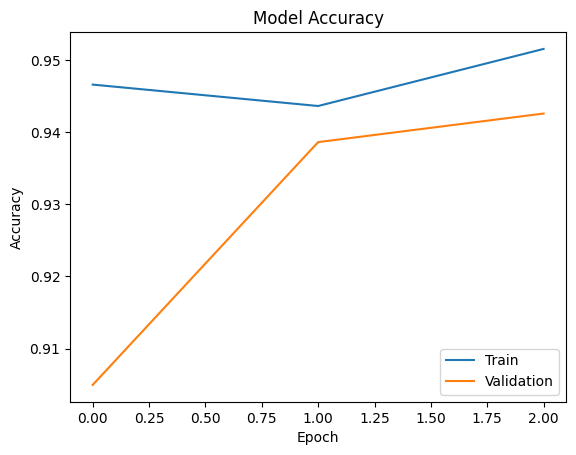

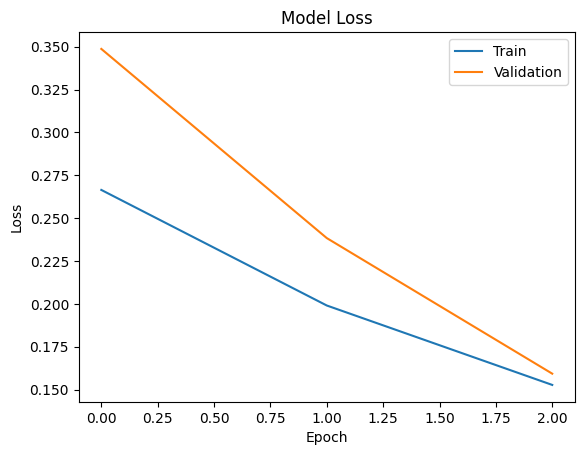

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

normalization_layer = layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))

model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(3, activation='softmax')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()



Task 4 –

Model Evaluation (6 Marks)

Evaluate the trained model using:

Confusion Matrix

Accuracy score

Sample predictions on test images

Deliverable:

• Confusion matrix visualization

• 5 test image predictions with predicted labels

Found 2527 files belonging to 3 classes.
Using 505 files for validation.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 806ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 809ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step
Model Accuracy: 0.9425742574257425


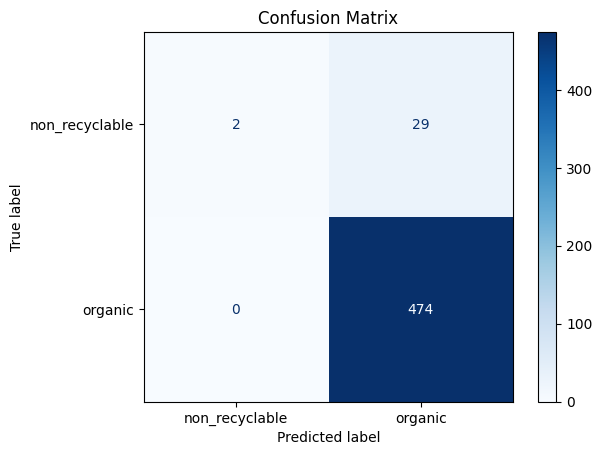

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 804ms/step


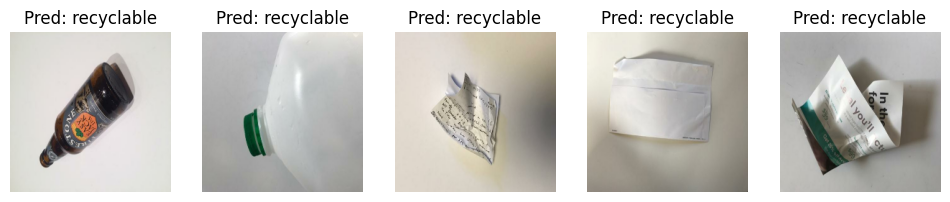

In [29]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Load validation dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

class_names = test_dataset.class_names

# Store labels and predictions
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Accuracy Score
accuracy = accuracy_score(y_true, y_pred)
print("Model Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

labels = test_dataset.class_names[:cm.shape[0]]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

# Show 5 Sample Predictions
plt.figure(figsize=(12,6))

for images, labels in test_dataset.take(1):

    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(5):

        plt.subplot(1,5,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title("Pred: " + class_names[predicted_labels[i]])
        plt.axis("off")

plt.show()

Task 5 –
Transfer Learning Implementation (6 Marks)

Improve your system by implementing Transfer Learning using a pretrained model such as:

ResNet50

MobileNetV2

VGG16

Steps:

Load a pretrained model

Freeze base layers

Add custom classification layers

Train the model

Compare results with your original CNN model.

Deliverable:

• Accuracy comparison between Custom CNN vs Transfer Learning mode

Found 2527 files belonging to 3 classes.
Using 2022 files for training.
Found 2527 files belonging to 3 classes.
Using 505 files for validation.


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.9357 - loss: 0.2082 - val_accuracy: 0.9525 - val_loss: 0.1323
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.9674 - loss: 0.1029 - val_accuracy: 0.9485 - val_loss: 0.1416
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9763 - loss: 0.0630 - val_accuracy: 0.9485 - val_loss: 0.1261

Accuracy Comparison
---------------------
Custom CNN Accuracy: 0.9425742626190186
Transfer Learning Accuracy: 0.9485148787498474


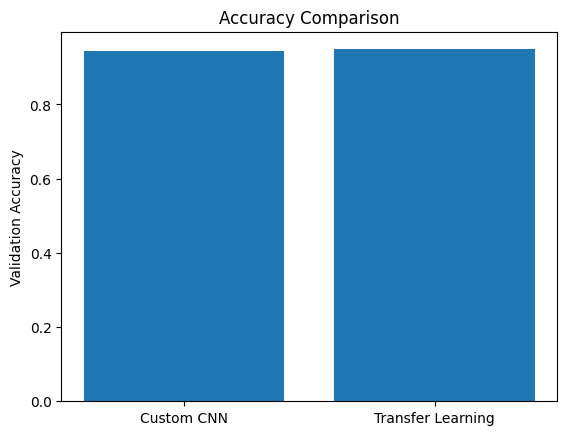

In [31]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

IMG_SIZE = (224,224)
BATCH_SIZE = 32

# Load dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
num_classes = len(class_names)

# Normalize
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x,y:(normalization_layer(x),y))
val_dataset = val_dataset.map(lambda x,y:(normalization_layer(x),y))


# -------------------------
# Load Pretrained Model
# -------------------------
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

# Freeze base layers
base_model.trainable = False


# -------------------------
# Add Custom Layers
# -------------------------
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(num_classes, activation='softmax')(x)

transfer_model = models.Model(inputs=base_model.input, outputs=output)


# Compile model
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Model summary
transfer_model.summary()


# -------------------------
# Train Transfer Model
# -------------------------
history_transfer = transfer_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)


# -------------------------
# Accuracy Comparison
# -------------------------

# Assume CNN model accuracy stored earlier
cnn_accuracy = history.history['val_accuracy'][-1]

transfer_accuracy = history_transfer.history['val_accuracy'][-1]

print("\nAccuracy Comparison")
print("---------------------")
print("Custom CNN Accuracy:", cnn_accuracy)
print("Transfer Learning Accuracy:", transfer_accuracy)


# -------------------------
# Plot Accuracy Comparison
# -------------------------

plt.bar(["Custom CNN","Transfer Learning"],
        [cnn_accuracy, transfer_accuracy])

plt.title("Accuracy Comparison")
plt.ylabel("Validation Accuracy")

plt.show()